# AZTEC for YT
This notebook loads a merged capacity traffic NumPy file and runs Block-1 training from the AZTEC+ framework.

Adjust the parameters below (lookback, delay, PHI, GAMMA, epochs) to suit your experiment.

In [1]:
import os
import sys
import numpy as np
from pprint import pprint
import tqdm
print('Python version:', sys.version.splitlines()[0])
print('Numpy version:', np.__version__)

Python version: 3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12) 
Numpy version: 1.22.4


In [2]:
import pandas as pd

# Path to the merged YT capacity traffic dataset
npy_path = '/home/jupyter-salcala/Distributed_learning/dataset/split_session/predictions/real_yt_data_capacity_traffic/kansaas_ready/merged_capacity_traffic.npy'

bordeaux = np.load(npy_path)
if bordeaux.ndim == 1:
    bordeaux = bordeaux.reshape(-1, 1)

# Clean missing / infinite values before scaling so the model does not train on NaNs.
raw_nan_count = np.isnan(bordeaux).sum()
raw_inf_count = np.isinf(bordeaux).sum()
if raw_nan_count or raw_inf_count:
    print(f'Raw data contains {raw_nan_count} NaNs and {raw_inf_count} inf values; interpolating them.')
    bordeaux = pd.DataFrame(bordeaux).replace([np.inf, -np.inf], np.nan)
    bordeaux = bordeaux.interpolate(axis=0, limit_direction='both').bfill().ffill().to_numpy()

print('Loaded dataset shape:', bordeaux.shape)
print('NaNs after cleanup:', np.isnan(bordeaux).sum())

# Use 80% of the series for training and 20% for testing
XTRAIN = round(len(bordeaux) * 0.8)
print('XTRAIN:', XTRAIN)

Raw data contains 9 NaNs and 0 inf values; interpolating them.
Loaded dataset shape: (63000, 1)
NaNs after cleanup: 0
XTRAIN: 50400


In [9]:
from tensorflow import keras
import tensorflow as tf
from keras import backend as K
from tensorflow.keras import layers, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time
import pickle

The next cells define the dataset split, LSTM/CNN builders, training loop, and prediction routine for the merged YT capacity traffic series.

In [10]:
# Model and forecasting parameters
LOOKBACK = 24  # longer history helps the model capture daily structure
DELAY = 6      # forecast horizon
PHI = 10       # negative slope of the loss function
GAMMA = 2      # positive slope of the loss function
NUM_SERV = bordeaux.shape[-1]
EPOCHS = 120   # fewer epochs plus early-style stability through a smaller LR
B = 50         # number of Monte Carlo outputs

# Split and normalize data
# Log-transform compresses large peaks while preserving zeros more naturally than plain MinMax scaling.
scaler = StandardScaler()
x_train = bordeaux[:XTRAIN]
x_test = bordeaux[XTRAIN:]

x_train_log = np.log1p(x_train)
x_test_log = np.log1p(x_test)

x_train_norm = tf.convert_to_tensor(scaler.fit_transform(x_train_log), dtype=tf.float32)
x_test_norm = tf.convert_to_tensor(scaler.transform(x_test_log), dtype=tf.float32)

# Build input, target, and test datasets
input_dataset = keras.preprocessing.timeseries_dataset_from_array(
    x_train_norm[:-DELAY],
    None,
    sequence_length=LOOKBACK,
    sequence_stride=DELAY
)

target_dataset = keras.preprocessing.timeseries_dataset_from_array(
    x_train_norm[LOOKBACK:],
    None,
    sequence_length=DELAY,
    sequence_stride=DELAY
)

test_dataset = keras.preprocessing.timeseries_dataset_from_array(
    x_test_norm[:-DELAY],
    None,
    sequence_length=LOOKBACK,
    sequence_stride=DELAY,
    batch_size=128
)

print('Train tensor:', x_train_norm.shape)
print('Test tensor:', x_test_norm.shape)
print('Input batches:', len(input_dataset))
print('Target batches:', len(target_dataset))
print('Test batches:', len(test_dataset))

Train tensor: (50400, 1)
Test tensor: (12600, 1)
Input batches: 66
Target batches: 66
Test batches: 17


In [11]:
def cost_func(y_true, y_pred, reduction='none'):
    slope = PHI
    gamma = GAMMA
    delta_x = 0.05
    forecast_delay = DELAY

    y_pred = tf.expand_dims(y_pred, axis=1)
    y_pred = tf.tile(y_pred, (1, forecast_delay, 1))
    cost = y_pred - y_true - delta_x
    pen_positive = gamma * cost
    pen_negative = slope * cost
    cost = tf.where(cost > 0, pen_positive, cost)
    cost = tf.where(cost <= 0, pen_negative, cost)
    cost = tf.abs(cost)
    cost = K.sum(K.sum(cost, axis=-1), axis=-1)
    return cost


def make_model_lstm(input_shape, lookback, num_services, phi=PHI):
    inputs = Input(shape=(lookback, num_services))
    x = layers.LSTM(128)(inputs)
    x = layers.Dropout(0.2)(x, training=True)
    x = layers.Dense(64, activation='relu')(x)
    output = layers.Dense(num_services)(x)
    model = Model(inputs, output)
    return model


def make_model_gru(input_shape, lookback, num_services):
    inputs = Input(shape=(lookback, num_services))
    x = layers.GRU(64, return_sequences=True)(inputs)
    x = layers.LayerNormalization()(x)
    x = layers.GRU(32)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.15)(x, training=True)
    x = layers.Dense(16, activation='relu')(x)
    output = layers.Dense(num_services)(x)
    model = Model(inputs, output)
    return model


def make_model_cnn(input_shape, lookback, num_services):
    inputs = Input(shape=(lookback, num_services))
    model = layers.Conv1D(32, 3, activation='relu', padding='same')(inputs)
    model = layers.Conv1D(32, 3, activation='relu', padding='same')(model)
    model = layers.Flatten()(model)
    model = layers.Dense(64, activation='relu')(model)
    model = layers.Dropout(0.3)(model, training=True)
    model = layers.Dense(32, activation='relu')(model)
    model = layers.Dropout(0.3)(model, training=True)
    output = layers.Dense(num_services)(model)
    model = Model(inputs, output)
    return model

MODEL_TYPE = 'GRU'  # stable default for noisy traffic series
if MODEL_TYPE == 'GRU':
    model = make_model_gru(x_train_norm.shape, LOOKBACK, NUM_SERV)
else:
    model = make_model_lstm(x_train_norm.shape, LOOKBACK, NUM_SERV)
model.summary()
optimizer = Adam(learning_rate=0.0001, clipnorm=1.0)

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 24, 1)]           0         
                                                                 
 gru_2 (GRU)                 (None, 24, 64)            12864     
                                                                 
 layer_normalization_1 (Laye  (None, 24, 64)           128       
 rNormalization)                                                 
                                                                 
 gru_3 (GRU)                 (None, 32)                9408      
                                                                 
 dense_3 (Dense)             (None, 32)                1056      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                           

In [6]:
for epoch in tqdm.tqdm(range(EPOCHS)):
    for step, (x_batch_train, y_batch_train) in enumerate(zip(input_dataset, target_dataset)):
        with tf.GradientTape() as tape:
            prediction = model(x_batch_train, training=True)
            loss_value = cost_func(y_batch_train, prediction)
        grads = tape.gradient(loss_value, model.trainable_weights)
        optimizer.apply_gradients(zip(grads, model.trainable_weights))

print('Training finished')

  0%|          | 0/120 [00:00<?, ?it/s]2026-05-29 19:05:52.842245: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8800
2026-05-29 19:05:54.389325: I tensorflow/stream_executor/cuda/cuda_blas.cc:1786] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
100%|██████████| 120/120 [03:23<00:00,  1.69s/it]

Training finished


0 (128, 24, 1)
1 (128, 24, 1)
2 (128, 24, 1)
3 (128, 24, 1)
4 (128, 24, 1)
5 (128, 24, 1)
6 (128, 24, 1)
7 (128, 24, 1)
8 (128, 24, 1)
9 (128, 24, 1)
10 (128, 24, 1)
11 (128, 24, 1)
12 (128, 24, 1)
13 (128, 24, 1)
14 (128, 24, 1)
15 (128, 24, 1)
16 (48, 24, 1)
Time taken for the forecast in seconds: 43.602686166763306


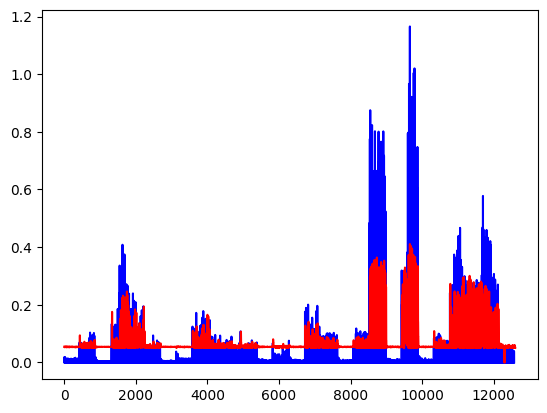

In [ ]:
start = time.time()

load_forecasted = np.zeros((int(x_test_norm.shape[0] / DELAY), NUM_SERV, B))
for idx, inputs in enumerate(test_dataset):
    print(idx, inputs.shape)
    for i in range(B):
        if inputs.shape[0] == 128:
            load_forecasted[idx * 128: (idx + 1) * 128, :, i] = model.predict(inputs, verbose=0)
        else:
            load_forecasted[-inputs.shape[0]:, :, i] = model.predict(inputs, verbose=0)

load_forecasted = np.repeat(load_forecasted, DELAY, axis=0)
end = time.time()
print('Time taken for the forecast in seconds:', end - start)

for service in range(min(NUM_SERV, 5)):
    plt.figure()
    plt.plot(x_test_norm[LOOKBACK:-DELAY, service], 'b')
    plt.plot(load_forecasted[:, service].mean(axis=-1), 'r')
plt.show()

np.save('./aztec_for_YT_forecast.npy', load_forecasted)
pickle.dump(scaler, open('./aztec_for_YT_log_standard_scaler.pkl', 'wb'))

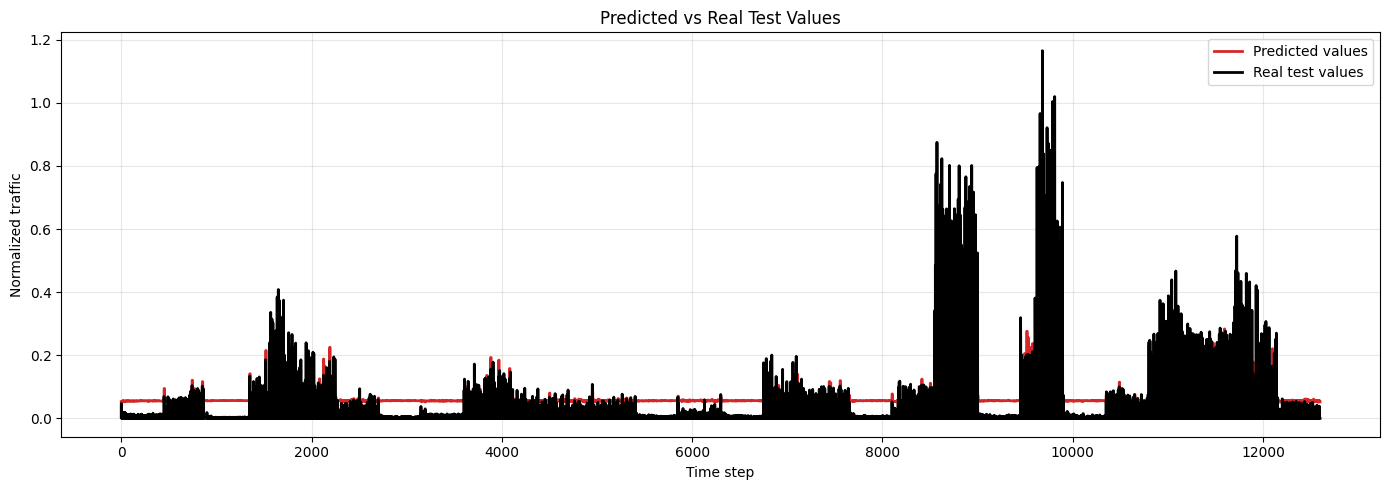

In [ ]:
# Compare predicted vs real test values in the original scale
real_test = x_test.reshape(-1)
pred_test_norm = load_forecasted.mean(axis=-1).reshape(-1, 1)
pred_test = np.expm1(scaler.inverse_transform(pred_test_norm)).reshape(-1)

n = min(len(real_test), len(pred_test))

plt.figure(figsize=(14, 5))
plt.plot(pred_test[:n], label='Predicted values', linewidth=2, color='tab:red')
plt.plot(real_test[:n], label='Real test values', linewidth=2, color='black')
plt.title('Predicted vs Real Test Values')
plt.xlabel('Time step')
plt.ylabel('Traffic')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Diagnostics for NaN inference
first_test_batch = next(iter(test_dataset))
if isinstance(first_test_batch, tuple):
    first_test_batch = first_test_batch[0]

first_pred = model.predict(first_test_batch, verbose=0)

print('x_train_norm has NaN:', np.isnan(x_train_norm.numpy()).any())
print('x_test_norm has NaN:', np.isnan(x_test_norm.numpy()).any())
print('first test batch has NaN:', np.isnan(first_test_batch.numpy()).any())
print('model prediction has NaN:', np.isnan(first_pred).any())
print('model prediction min/max:', np.nanmin(first_pred), np.nanmax(first_pred))
print('first batch min/max:', np.nanmin(first_test_batch.numpy()), np.nanmax(first_test_batch.numpy()))

x_train_norm has NaN: False
x_test_norm has NaN: False
first test batch has NaN: False
model prediction has NaN: False
model prediction min/max: -0.31833807 0.8629199
first batch min/max: -0.6898476 1.9063876
